# EDA

Perform EDA on the data provided. This includes:
- Viewing raw data samples
- Identifying data quality issues (duplicates, missing values, data types)
- Validating referential integrity across source systems
- Profiling key metrics and distributions
- Auditing the customer linkage table coverage

Outputs from this notebook are saved onto `plots` folder

In [116]:
import os
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs('plots', exist_ok=True)

## Load Datasets

In [117]:
# Get the current directory
current_directory = os.getcwd()
path = os.path.join(current_directory, "datasets")
print(f"Fetching data from directory: {path}")

# ... TICKETMASTER ...
# `ticket_purchases`: Online ticket purchases per event
ticket_purchases_df = pd.read_csv(f"{path}/ticket_purchases.csv")
print(f"... `ticket_purchases.csv` loaded {ticket_purchases_df.shape}")

# `event_attendance`: Attendance scan-ins by customers
event_attendance_df = pd.read_csv(f"{path}/event_attendance.csv")
print(f"... `event_attendance.csv` loaded {event_attendance_df.shape}")

# `events`: Metadata for each event
events_df = pd.read_csv(f"{path}/events.csv")
print(f"... `events.csv` loaded {events_df.shape}")

# ... SALESFORCE CRM ...
# `crm_interactions`: Contact history and opportunity stages
crm_interactions_df = pd.read_csv(f"{path}/crm_interactions.csv")
print(f"... `crm_interactions.csv` loaded {crm_interactions_df.shape}")

# ... GOOGLE ANALYTICS ...
# `web_sessions`: Website sessions including source, duration, and engagement
web_sessions_df = pd.read_csv(f"{path}/web_sessions.csv")
print(f"... `web_sessions.csv` loaded {web_sessions_df.shape}")

# ... RETAIL POS ...
# `retail_transactions`: In-venue or merchandise store purchases
retail_transactions_df = pd.read_csv(f"{path}/retail_transactions.csv")
print(f"... `retail_transactions.csv` loaded {retail_transactions_df.shape}")

# ... CUSTOMER PROFILES ...
# `customers`: Partial demographic and signup metadata across systems
customers_df = pd.read_csv(f"{path}/customers.csv")
print(f"... `customers.csv` loaded {customers_df.shape}")

# ... CUSTOMER LINKAGE ...
# `customer_linkage`: A mapping table linking system-specific customer IDs to a shared universal_id
customer_linkage_df = pd.read_csv(f"{path}/customer_linkage.csv")
print(f"... `customer_linkage.csv` loaded {customer_linkage_df.shape}")

Fetching data from directory: /Users/wildg/Desktop/compass-analytics-interview/datasets
... `ticket_purchases.csv` loaded (500, 4)
... `event_attendance.csv` loaded (600, 3)
... `events.csv` loaded (50, 3)
... `crm_interactions.csv` loaded (400, 4)
... `web_sessions.csv` loaded (1000, 5)
... `retail_transactions.csv` loaded (700, 5)
... `customers.csv` loaded (200, 5)
... `customer_linkage.csv` loaded (120, 5)


## Raw Data Samples

View the first few rows of each dataset to understand the data structure

In [118]:
datasets = {
  "ticket_purchases": ticket_purchases_df,
  "event_attendance": event_attendance_df,
  "events": events_df,
  "crm_interactions": crm_interactions_df,
  "web_sessions": web_sessions_df,
  "retail_transactions": retail_transactions_df,
  "customers": customers_df,
  "customer_linkage": customer_linkage_df
}

for name, df in datasets.items():
  print(f"===== {name} =====")
  display(df.head(3))
  print()

===== ticket_purchases =====


,customer_id,event_id,purchase_date,ticket_amount
0,tmc_00d9e230,evt_314081a9,2024-11-25,60.85
1,tmc_00d9e230,evt_cdedfbf7,2023-03-07,204.03
2,tmc_01835e69,evt_0cb72b53,2024-11-30,42.68



===== event_attendance =====


,customer_id,event_id,scan_timestamp
0,tmc_053ec30f,evt_9091d14e,2024-07-02
1,tmc_f3f735d8,evt_66f17cf8,2022-11-22
2,tmc_10557f84,evt_1787d2ff,2024-08-30



===== events =====


...

,customer_id,transaction_date,location,amount,product_category
0,rtc_de27f658,2022-08-29,Stadium C,159.55,Drink
1,rtc_9d34707d,2024-09-07,Stadium A,41.45,Souvenir
2,rtc_5d2685eb,2023-05-12,Stadium C,18.00,Apparel



===== customers =====


,customer_id,signup_date,city,gender,age_group
0,tmc_b20cc720,2025-05-27,Toronto,Female,18-24
1,tmc_34457841,2024-11-09,Toronto,Female,55+
2,tmc_c1651ef7,2023-01-22,Vancouver,Other,55+



===== customer_linkage =====


,universal_id,tmc_id,sfc_id,gac_id,rtc_id
0,cust_0000,tmc_41637348,sfc_5c688db9,gac_5c165a23,rtc_e1ff560e
1,cust_0001,tmc_a458e1cc,sfc_11b3cfa3,NaN,rtc_5d2685eb
2,cust_0002,tmc_5fdfdc30,sfc_184cf634,gac_f820c17c,rtc_820d29e4


## Data Quality Issues

Validate the data quality by checking for duplicates, missing values, and data types

In [119]:
# Loop through each dataset and print information about each column
for name, df in datasets.items():
  print(f"===== {name} COLUMN INFO =====")
  display(df.info(memory_usage=False))

===== ticket_purchases COLUMN INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customer_id    500 non-null    object 
 1   event_id       500 non-null    object 
 2   purchase_date  500 non-null    object 
 3   ticket_amount  500 non-null    float64
dtypes: float64(1), object(3)

None

===== event_attendance COLUMN INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     600 non-null    object
 1   event_id        600 non-null    object
 2   scan_timestamp  600 non-null    object
dtypes: object(3)

None

===== events COLUMN INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   event_id    50 non-null     object
 1   event_type  50 non-null     object
 2   event_date  50 non-null     object
dtypes: object(3)

...

None

===== customers COLUMN INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  200 non-null    object
 1   signup_date  200 non-null    object
 2   city         200 non-null    object
 3   gender       200 non-null    object
 4   age_group    200 non-null    object
dtypes: object(5)

None

===== customer_linkage COLUMN INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   universal_id  120 non-null    object
 1   tmc_id        93 non-null     object
 2   sfc_id        94 non-null     object
 3   gac_id        95 non-null     object
 4   rtc_id        99 non-null     object
dtypes: object(5)

None

In [120]:
# Loop through each dataset and check for duplicates
for name, df in datasets.items():
    duplicates = df.duplicated().sum()
    print(f"{name} has {duplicates} duplicate rows.")

ticket_purchases has 0 duplicate rows.
event_attendance has 0 duplicate rows.
events has 0 duplicate rows.
crm_interactions has 0 duplicate rows.
web_sessions has 0 duplicate rows.
retail_transactions has 0 duplicate rows.
customers has 0 duplicate rows.
customer_linkage has 0 duplicate rows.


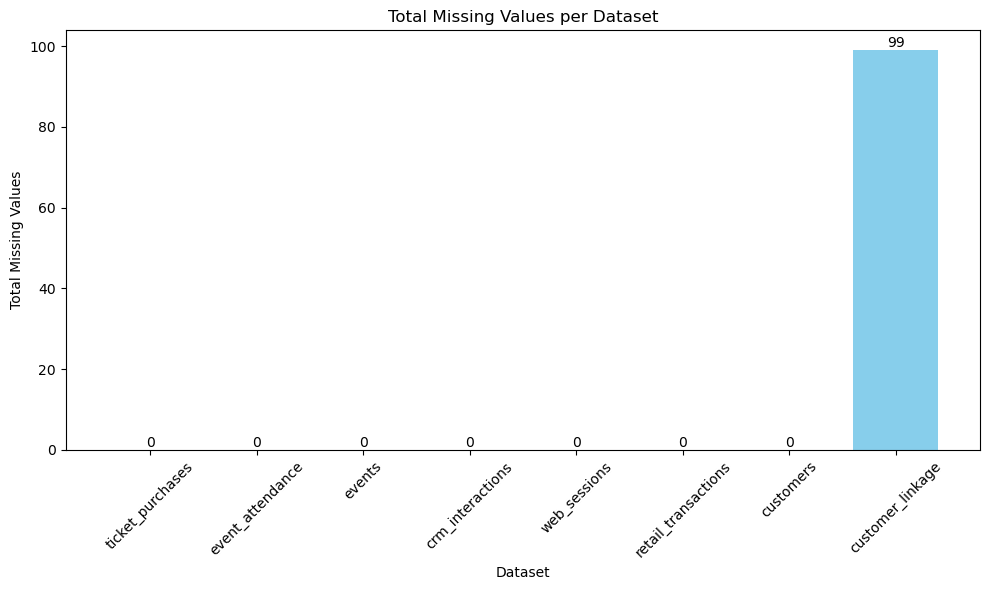

In [121]:
total_missing_data = {}

# Loop through each dataset and count missing values
for name, df in datasets.items():
  total_missing_data[name] = df.isnull().sum().sum()

# Plot the total_missing_data
plt.figure(figsize=(10, 6))
bars = plt.bar(
  total_missing_data.keys(),
  total_missing_data.values(),
  color='skyblue'
)

plt.bar_label(bars)
plt.xlabel('Dataset')
plt.ylabel('Total Missing Values')
plt.title('Total Missing Values per Dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/total_missing_values.png')
plt.show()

#### Per-Column Missing Value Breakdown

For datasets with missing values, show exactly which columns are affected

In [122]:
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"===== {name} =====")
        for col, count in missing.items():
            print(f"  {col}: {count} missing ({count / len(df) * 100:.1f}%)")
        print()

===== customer_linkage =====
  tmc_id: 27 missing (22.5%)
  sfc_id: 26 missing (21.7%)
  gac_id: 25 missing (20.8%)
  rtc_id: 21 missing (17.5%)



## Customer ID Prefix Analysis

Each source system uses a distinct prefix for its customer IDs:
- `tmc_` = Ticketmaster (ticket_purchases, event_attendance)
- `sfc_` = Salesforce CRM (crm_interactions)
- `gac_` = Google Analytics (web_sessions)
- `rtc_` = Retail POS (retail_transactions)

This means direct `customer_id` comparisons across source systems are not valid. The `customer_linkage` table is needed to resolve IDs across systems

In [123]:
# Verify that each source table uses a single, expected prefix
source_prefix_map = {
    "ticket_purchases": "tmc_",
    "event_attendance": "tmc_",
    "crm_interactions": "sfc_",
    "web_sessions": "gac_",
    "retail_transactions": "rtc_",
}

for name, expected_prefix in source_prefix_map.items():
    df = datasets[name]
    prefixes = df['customer_id'].str[:4].unique()
    status = "OK" if len(prefixes) == 1 and prefixes[0] == expected_prefix else "UNEXPECTED"
    print(f"{name}: prefixes={list(prefixes)} (expected: {expected_prefix}) [{status}]")

ticket_purchases: prefixes=['tmc_'] (expected: tmc_) [OK]
event_attendance: prefixes=['tmc_'] (expected: tmc_) [OK]
crm_interactions: prefixes=['sfc_'] (expected: sfc_) [OK]
web_sessions: prefixes=['gac_'] (expected: gac_) [OK]
retail_transactions: prefixes=['rtc_'] (expected: rtc_) [OK]


#### `customers.csv` is Multi-System

`customers.csv` contains demographic data sourced from ALL four systems, not just one. Thus, we can join demographics by matching the prefix-appropriate ID, not by a single universal key

In [124]:
# Show breakdown of prefixes in customers.csv
prefix_counts = customers_df['customer_id'].str[:4].value_counts()
print("=== customers.csv prefix breakdown ===")
print(prefix_counts)
print(f"\nTotal: {len(customers_df)} rows across {len(prefix_counts)} systems")

=== customers.csv prefix breakdown ===
customer_id
tmc_    50
sfc_    50
gac_    50
rtc_    50
Name: count, dtype: int64

Total: 200 rows across 4 systems


## Orphaned Customer Profiles

Check for customer_ids in `customers_df` that have no activity in any of the source activity tables (ticket_purchases, event_attendance, crm_interactions, web_sessions, retail_transactions). We exclude `customers` and `customer_linkage` from the activity pool

In [125]:
activity_tables = {
    name: df for name, df in datasets.items()
    if name not in ('customers', 'customer_linkage', 'events')
       and 'customer_id' in df.columns
}

customer_ids = set(customers_df['customer_id'])
active_customer_ids = set()
for name, df in activity_tables.items():
    active_customer_ids.update(df['customer_id'].unique())

orphaned_customer_ids = customer_ids - active_customer_ids
print(f"Customer profiles with no activity in any source table: {len(orphaned_customer_ids)}")
if len(orphaned_customer_ids) > 0:
    print(f"Sample orphaned IDs: {list(orphaned_customer_ids)[:10]}")

Customer profiles with no activity in any source table: 5
Sample orphaned IDs: ['sfc_d2a9ecb3', 'rtc_e66292f8', 'sfc_cb3c90db', 'sfc_a3794a00', 'gac_dcf43e1d']


## Reused Customer IDs per Dataset

Check how many customer_ids appear more than once in each activity table. This is expected for transactional tables (one customer can have many purchases)

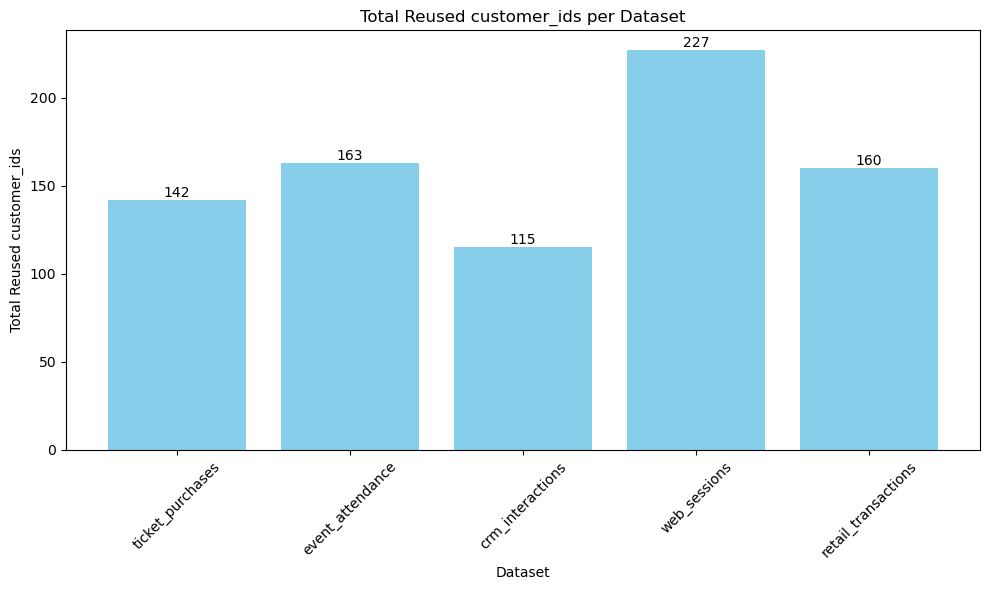

In [126]:
# Check how many `customer_id`s are re-used in more than one row per dataframe
reused_customer_ids = {}

for name, df in activity_tables.items():
  counts = df['customer_id'].value_counts()
  reused_customer_ids[name] = (counts > 1).sum()

# Plot the reused_customer_ids
plt.figure(figsize=(10, 6))
bars = plt.bar(
  reused_customer_ids.keys(),
  reused_customer_ids.values(),
  color='skyblue'
)

plt.bar_label(bars)
plt.xlabel('Dataset')
plt.ylabel('Total Reused customer_ids')
plt.title('Total Reused customer_ids per Dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/reused_customer_ids.png')
plt.show()

## Cross-System Coverage via Linkage Table

Since each source table uses a different ID prefix, direct comparisons are meaningless. Instead, we check what percentage of each source system's IDs can be resolved through the `customer_linkage` table to a `universal_id`

In [127]:
# Map each source table to the corresponding linkage column
source_to_linkage_col = {
    "ticket_purchases": "tmc_id",
    "event_attendance": "tmc_id",
    "crm_interactions": "sfc_id",
    "web_sessions": "gac_id",
    "retail_transactions": "rtc_id",
}

coverage_results = {}

for source_name, linkage_col in source_to_linkage_col.items():
    df = datasets[source_name]
    source_ids = set(df['customer_id'].unique())
    linkage_ids = set(customer_linkage_df[linkage_col].dropna().unique())

    matched = source_ids & linkage_ids
    unmatched = source_ids - linkage_ids

    coverage_pct = len(matched) / len(source_ids) * 100 if len(source_ids) > 0 else 0
    coverage_results[source_name] = {
        'total_unique_ids': len(source_ids),
        'matched_in_linkage': len(matched),
        'unmatched': len(unmatched),
        'coverage_pct': coverage_pct,
        'linkage_col': linkage_col
    }
    print(f"{source_name} ({linkage_col}):")
    print(f"  Unique IDs: {len(source_ids)}")
    print(f"  Matched in linkage: {len(matched)} ({coverage_pct:.1f}%)")
    print(f"  Unmatched: {len(unmatched)}")
    print()

ticket_purchases (tmc_id):
  Unique IDs: 181
  Matched in linkage: 84 (46.4%)
  Unmatched: 97

event_attendance (tmc_id):
  Unique IDs: 193
  Matched in linkage: 90 (46.6%)
  Unmatched: 103

crm_interactions (sfc_id):
  Unique IDs: 138
  Matched in linkage: 85 (61.6%)
  Unmatched: 53

web_sessions (gac_id):
  Unique IDs: 245
  Matched in linkage: 94 (38.4%)
  Unmatched: 151

retail_transactions (rtc_id):
  Unique IDs: 176
  Matched in linkage: 97 (55.1%)
  Unmatched: 79



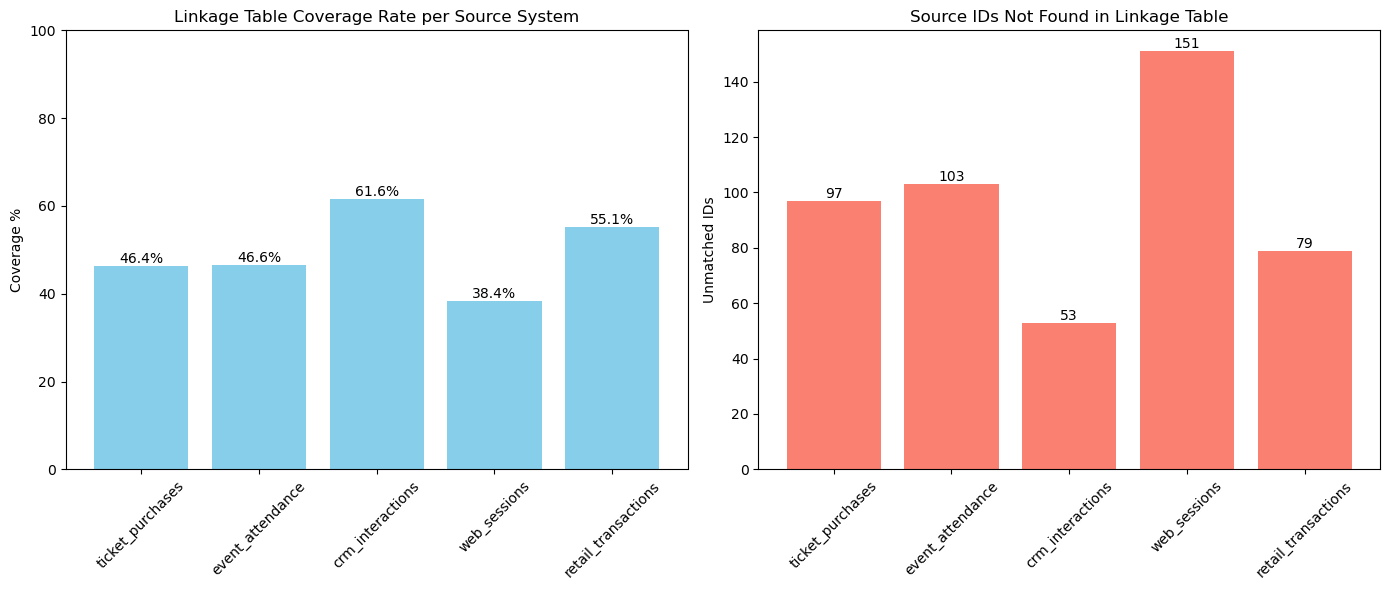

In [128]:
# Plot linkage coverage rates
names = list(coverage_results.keys())
coverages = [coverage_results[n]['coverage_pct'] for n in names]
unmatched_counts = [coverage_results[n]['unmatched'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Coverage percentage
bars1 = axes[0].bar(names, coverages, color='skyblue')
axes[0].bar_label(bars1, fmt='%.1f%%')
axes[0].set_ylabel('Coverage %')
axes[0].set_title('Linkage Table Coverage Rate per Source System')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=45)

# Unmatched counts
bars2 = axes[1].bar(names, unmatched_counts, color='salmon')
axes[1].bar_label(bars2)
axes[1].set_ylabel('Unmatched IDs')
axes[1].set_title('Source IDs Not Found in Linkage Table')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('plots/linkage_coverage.png')
plt.show()

**Key Finding**: A significant portion of source-system IDs are NOT present in the linkage table. This means the C360 build will lose data for these customers unless a fallback strategy is used (e.g., creating single-system records without cross-system linkage)

## Customer Linkage Table Deep Dive

In [129]:
print(f"Linkage table rows: {len(customer_linkage_df)}")
print(f"Unique universal_ids: {customer_linkage_df['universal_id'].nunique()}")
print()

# Check for NaN counts per linkage column
print("=== NaN counts per column ===")
print(customer_linkage_df.isnull().sum())
print()

# Check for duplicate source-system IDs within each linkage column
# (would indicate the same source ID mapped to multiple universal_ids)
print("=== Duplicate source IDs within linkage columns ===")
for col in ['tmc_id', 'sfc_id', 'gac_id', 'rtc_id']:
    vals = customer_linkage_df[col].dropna()
    dupes = vals[vals.duplicated()]
    print(f"  {col}: {len(dupes)} duplicates")

print()

# Check if universal_id is truly unique
uni_dupes = customer_linkage_df['universal_id'].duplicated().sum()
print(f"Duplicate universal_ids: {uni_dupes}")

Linkage table rows: 120
Unique universal_ids: 120

=== NaN counts per column ===
universal_id     0
tmc_id          27
sfc_id          26
gac_id          25
rtc_id          21
dtype: int64

=== Duplicate source IDs within linkage columns ===
  tmc_id: 0 duplicates
  sfc_id: 0 duplicates
  gac_id: 0 duplicates
  rtc_id: 0 duplicates

Duplicate universal_ids: 0


#### Linkage Completeness

How many linkage rows have all 4 system IDs filled vs. partial matches

=== Systems linked per universal_id ===
  1 systems: 6 customers
  2 systems: 21 customers
  3 systems: 39 customers
  4 systems: 54 customers


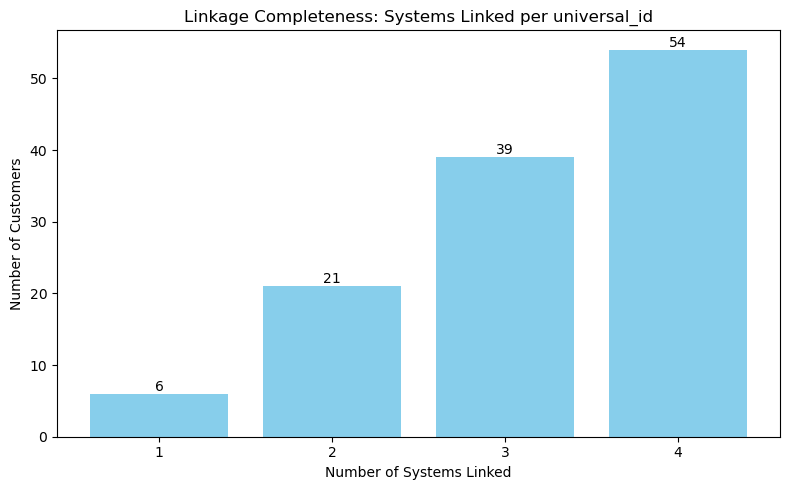

In [130]:
id_cols = ['tmc_id', 'sfc_id', 'gac_id', 'rtc_id']

# Count how many system IDs are filled per row
customer_linkage_df['systems_linked'] = customer_linkage_df[id_cols].notna().sum(axis=1)
completeness = customer_linkage_df['systems_linked'].value_counts().sort_index()

print("=== Systems linked per universal_id ===")
for num_systems, count in completeness.items():
    print(f"  {num_systems} systems: {count} customers")

plt.figure(figsize=(8, 5))
bars = plt.bar(completeness.index, completeness.values, color='skyblue')
plt.bar_label(bars)
plt.xlabel('Number of Systems Linked')
plt.ylabel('Number of Customers')
plt.title('Linkage Completeness: Systems Linked per universal_id')
plt.xticks(completeness.index)
plt.tight_layout()
plt.savefig('plots/linkage_completeness.png')
plt.show()

# Clean up temp column
customer_linkage_df.drop(columns=['systems_linked'], inplace=True)

## Date Range and Temporal Analysis

Understanding the time span of each dataset is critical for Task 2. Features like "last 90 days retail purchases" and "days since last interaction" depend on knowing the reference date and whether there are future-dated or implausibly old records

In [131]:
# Parse dates and show min/max per dataset
date_columns = {
    "ticket_purchases": "purchase_date",
    "event_attendance": "scan_timestamp",
    "events": "event_date",
    "crm_interactions": "contact_date",
    "web_sessions": "session_date",
    "retail_transactions": "transaction_date",
    "customers": "signup_date",
}

date_ranges = {}

for name, date_col in date_columns.items():
    df = datasets[name]
    dates = pd.to_datetime(df[date_col], errors='coerce')
    n_invalid = dates.isna().sum() - df[date_col].isna().sum()  # dates that failed parsing
    date_ranges[name] = {
        'column': date_col,
        'min': dates.min(),
        'max': dates.max(),
        'invalid_dates': n_invalid,
        'span_days': (dates.max() - dates.min()).days
    }
    print(f"{name} ({date_col}):")
    print(f"  Range: {dates.min().date()} to {dates.max().date()} ({(dates.max() - dates.min()).days} days)")
    if n_invalid > 0:
        print(f"  WARNING: {n_invalid} unparseable date values")
    print()

ticket_purchases (purchase_date):
  Range: 2022-01-01 to 2025-06-30 (1276 days)

event_attendance (scan_timestamp):
  Range: 2022-01-03 to 2025-06-30 (1274 days)

events (event_date):
  Range: 2022-01-14 to 2025-05-21 (1223 days)

crm_interactions (contact_date):
  Range: 2022-01-06 to 2025-06-27 (1268 days)

web_sessions (session_date):
  Range: 2022-01-04 to 2025-06-30 (1273 days)

retail_transactions (transaction_date):
  Range: 2022-01-02 to 2025-06-24 (1269 days)

customers (signup_date):
  Range: 2022-01-03 to 2025-06-29 (1273 days)



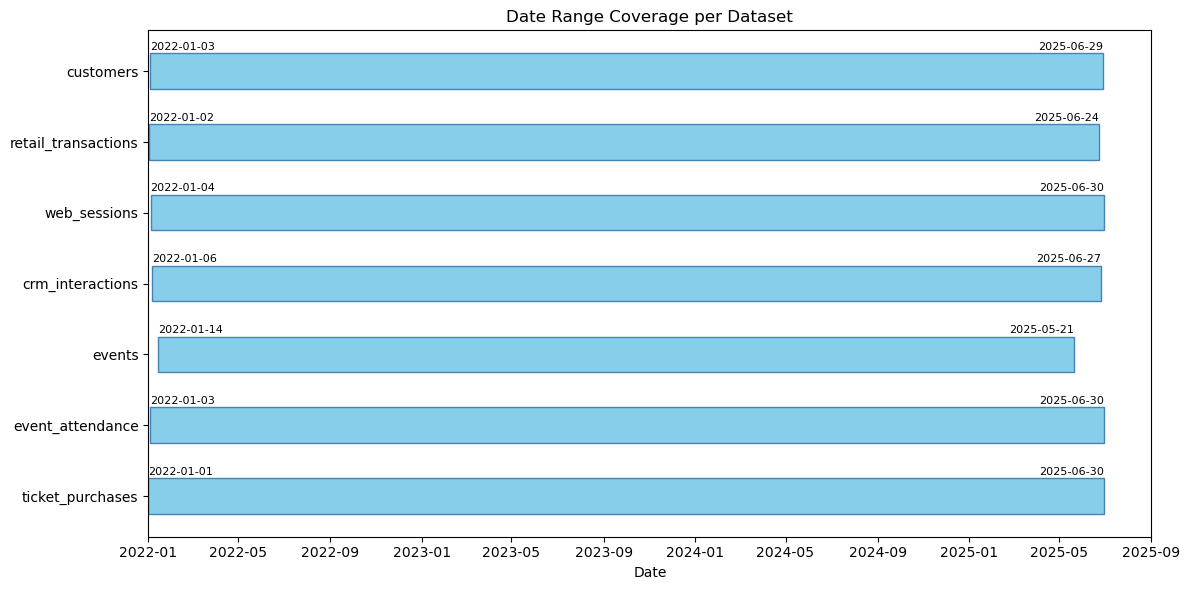

In [132]:
# Visualize the date ranges as a timeline
fig, ax = plt.subplots(figsize=(12, 6))
names = list(date_ranges.keys())
for i, name in enumerate(names):
    dr = date_ranges[name]
    ax.barh(i, (dr['max'] - dr['min']).days,
            left=dr['min'], height=0.5, color='skyblue', edgecolor='steelblue')
    ax.text(dr['min'], i + 0.3, dr['min'].strftime('%Y-%m-%d'), fontsize=8)
    ax.text(dr['max'], i + 0.3, dr['max'].strftime('%Y-%m-%d'), fontsize=8, ha='right')

ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.set_xlabel('Date')
ax.set_title('Date Range Coverage per Dataset')
plt.tight_layout()
plt.savefig('plots/date_ranges.png')
plt.show()

## Referential Integrity Checks

Validate that foreign keys in transactional tables actually reference valid records in their parent tables

#### Event ID Validation

Check whether all `event_id`s in `ticket_purchases` and `event_attendance` exist in `events.csv`

In [133]:
valid_event_ids = set(events_df['event_id'].unique())

for name in ['ticket_purchases', 'event_attendance']:
    df = datasets[name]
    source_event_ids = set(df['event_id'].unique())
    missing = source_event_ids - valid_event_ids
    print(f"{name}:")
    print(f"  Unique event_ids: {len(source_event_ids)}")
    print(f"  Found in events.csv: {len(source_event_ids & valid_event_ids)}")
    print(f"  NOT in events.csv: {len(missing)}")
    if len(missing) > 0:
        print(f"  Missing event_ids: {list(missing)[:5]}...")
    print()

ticket_purchases:
  Unique event_ids: 50
  Found in events.csv: 50
  NOT in events.csv: 0

event_attendance:
  Unique event_ids: 50
  Found in events.csv: 50
  NOT in events.csv: 0



## Customer Presence Across Source Systems

For each `customer_id`, track which source activity tables they appear in. Since IDs are system-specific, a customer will only appear in tables that share their prefix. This helps us understand single-system vs. multi-system presence *before* linkage resolution

In [134]:
# Track customer_id presence across activity tables
customer_id_presence = {}
for name, df in activity_tables.items():
    for cid in df['customer_id'].unique():
        if cid not in customer_id_presence:
            customer_id_presence[cid] = []
        customer_id_presence[cid].append(name)

# Sort table names within each combination for consistent labeling
for cid in customer_id_presence:
    customer_id_presence[cid] = sorted(customer_id_presence[cid])

# Count the number of unique combination patterns
combination_counts = {}
for tables in customer_id_presence.values():
    key = ", ".join(tables)
    combination_counts[key] = combination_counts.get(key, 0) + 1

# Sort by count descending
combination_counts = dict(sorted(combination_counts.items(), key=lambda x: x[1], reverse=True))

print(f"Total unique customer_ids across all activity tables: {len(customer_id_presence)}")
print(f"Unique presence combinations: {len(combination_counts)}")
print()
for combo, count in combination_counts.items():
    print(f"  {combo}: {count} customers")

Total unique customer_ids across all activity tables: 758
Unique presence combinations: 6

  web_sessions: 245 customers
  retail_transactions: 176 customers
  event_attendance, ticket_purchases: 175 customers
  crm_interactions: 138 customers
  event_attendance: 18 customers
  ticket_purchases: 6 customers


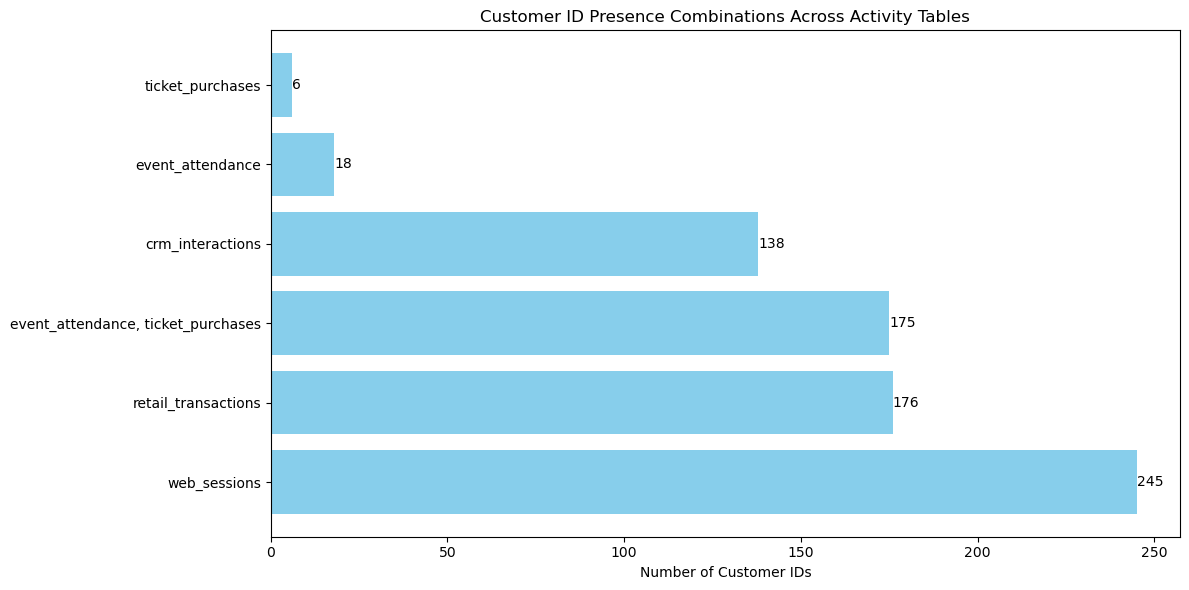

In [135]:
# Plot the top combinations
plt.figure(figsize=(12, 6))
bars = plt.barh(
    list(combination_counts.keys()),
    list(combination_counts.values()),
    color='skyblue'
)
plt.bar_label(bars)
plt.xlabel('Number of Customer IDs')
plt.title('Customer ID Presence Combinations Across Activity Tables')
plt.tight_layout()
plt.savefig('plots/customer_id_presence.png')
plt.show()

## Event Ticket Purchase vs. Attendance

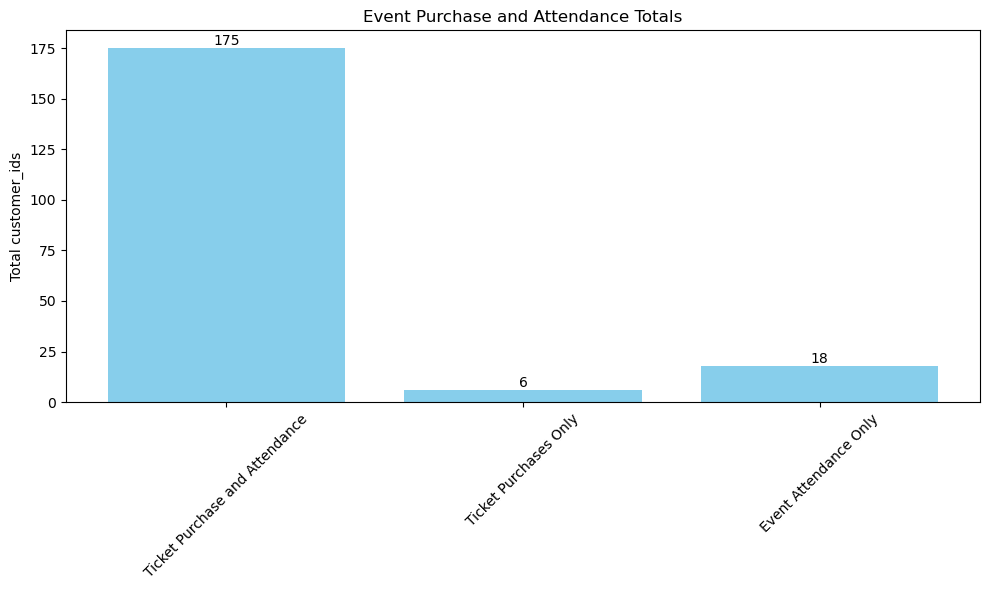

In [136]:
# Calculate the counts
ticket_purchases_customer_ids = set(ticket_purchases_df['customer_id'])
event_attendance_customer_ids = set(event_attendance_df['customer_id'])

both_purchase_and_attendance = ticket_purchases_customer_ids & event_attendance_customer_ids
ticket_purchases_not_in_attendance = ticket_purchases_customer_ids - event_attendance_customer_ids
event_attendance_not_in_ticket_purchases = event_attendance_customer_ids - ticket_purchases_customer_ids

# Structure data for plotting
plot_data = {
    'Ticket Purchase and Attendance': len(both_purchase_and_attendance),
    'Ticket Purchases Only': len(ticket_purchases_not_in_attendance),
    'Event Attendance Only': len(event_attendance_not_in_ticket_purchases)
}

# Plot the event ticket purchase and attendance counts
plt.figure(figsize=(10, 6))
bars = plt.bar(
  plot_data.keys(),
  plot_data.values(),
  color='skyblue'
)

plt.bar_label(bars)
plt.ylabel('Total customer_ids')
plt.title('Event Purchase and Attendance Totals')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/event_purchase_and_attendance_totals.png')
plt.show()

- Somebody can buy tickets without attending events. Currently, there are customer_ids in `ticket_purchases_df` that are not in `event_attendance_df`. This could be due to cancellations, no-shows, or gifting the ticket to another customer
- Somebody can attend an event without buying a ticket. Currently, there are customer_ids in `event_attendance_df` that are not in `ticket_purchases_df`. This could be due to complimentary tickets or attending an event without a recorded purchase

#### Event-Level: Purchased vs. Attended (per event_id)

In [137]:
# For each event, compare who purchased vs. who attended
event_ids = events_df['event_id'].unique()
event_stats = []

for eid in event_ids:
    purchasers = set(ticket_purchases_df[ticket_purchases_df['event_id'] == eid]['customer_id'])
    attendees = set(event_attendance_df[event_attendance_df['event_id'] == eid]['customer_id'])
    event_stats.append({
        'event_id': eid,
        'purchasers': len(purchasers),
        'attendees': len(attendees),
        'purchased_and_attended': len(purchasers & attendees),
        'purchased_not_attended': len(purchasers - attendees),
        'attended_not_purchased': len(attendees - purchasers),
    })

event_stats_df = pd.DataFrame(event_stats)
print("=== Event-Level Purchase vs. Attendance Counts ===")
display(event_stats_df.set_index('event_id'))

=== Event-Level Purchase vs. Attendance Counts ===


,purchasers,attendees,purchased_and_attended,purchased_not_attended,attended_not_purchased
event_id,,,,,
evt_7a3bab3d,11,9,1,10,8
evt_0cb72b53,8,17,3,5,14
evt_e6ebda47,11,12,0,11,12
evt_314081a9,9,14,1,8,13
evt_c583240e,12,11,0,12,11
evt_6697838a,12,8,1,11,7
evt_abc3e1e7,5,9,0,5,9
evt_d9ce5183,11,16,3,8,13
evt_5d64d80e,8,11,1,7,10
